# Phase 6.5 â€” Haul-Probability Classifiers

`notebooks/09_error_analysis.ipynb` found the deployed `total_points_direct` regressor (RÂ²=0.320) is structurally haul-blind: for actual 11+ point hauls, its mean prediction is only ~3, about a quarter of what happened. That's not a missing-feature problem, it's an MSE-on-a-right-skewed-target problem â€” hedging toward the mean costs less in squared error than confidently guessing big and being wrong sometimes.

This notebook covers the fix: instead of asking one regressor to also nail the exact magnitude, train classifiers for a different, answerable question â€” how *likely* is a big score.

In [1]:
import sys
import warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore", message=".*only supports SQLAlchemy.*")

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import psycopg2
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss

from config import settings
from src.features.historical_features import FEATURE_COLS, build_training_frame
from src.models.train import TEST_SEASON, TRAIN_SEASONS

conn = psycopg2.connect(settings.DATABASE_URL)
pd.set_option("display.width", 120)

## Did better features fix it? (No â€” tested and ruled out first)

Before building a classifier, `threat_roll{3,5}` / `creativity_roll{3,5}` (FPL's own attacking sub-indices, already summed into `ict_index` but never exposed as separate rolling signals) were added to the regressor's feature set on the theory that a rising shot/chance-creation trend might be a haul precursor the blended index couldn't isolate.

**Result: RÂ² unchanged, 0.320 â†’ 0.320.** Confirms the diagnosis â€” this is an objective-function limitation, not a feature-availability one.

## Model comparison: baseline / logistic / Random Forest / XGBoost

Same train/test split as the regressor (train on 2020-21 through 2024-25, test on the entire held-out 2025-26 season), same feature set. Two thresholds: a "good return" (6+ points) and a genuine "haul" (10+ points).

In [2]:
versions = pd.read_sql_query(
    "SELECT DISTINCT ON (model_type, target) model_type, target, roc_auc, brier_score, trained_at "
    "FROM model_versions WHERE target IN ('haul_6plus', 'haul_10plus') "
    "ORDER BY model_type, target, trained_at DESC", conn
)
for target in ["haul_6plus", "haul_10plus"]:
    print(f"--- {target} ---")
    display(versions[versions["target"] == target].sort_values("brier_score")
            [["model_type", "roc_auc", "brier_score"]])
    print()

--- haul_6plus ---


,model_type,roc_auc,brier_score
7,xgboost,0.8602,0.0564
1,baseline,0.5000,0.0651
3,logistic_regression,0.8573,0.1520
5,random_forest,0.8583,0.1607



--- haul_10plus ---


,model_type,roc_auc,brier_score
6,xgboost,0.8445,0.0173
0,baseline,0.5000,0.0179
2,logistic_regression,0.8468,0.1455
4,random_forest,0.8494,0.1537


## Why XGBoost, not the highest-AUC model

Random Forest and logistic regression used `class_weight="balanced"` to separate the (rare) haul class better â€” it worked for ROC-AUC, but at a real calibration cost: their Brier scores (~0.15) are far worse than XGBoost's (~0.02â€“0.06), which trained on the natural class imbalance directly. A displayed "23% chance of a haul" is only useful if it roughly means 1-in-5 â€” **XGBoost was selected by Brier score (calibration), not ROC-AUC (ranking)**, since this is a number shown directly to a human making a decision, not just an internal ranking signal.

The chart below is the direct evidence: bucket the held-out test set by predicted probability, and check whether the actual observed frequency in each bucket matches.

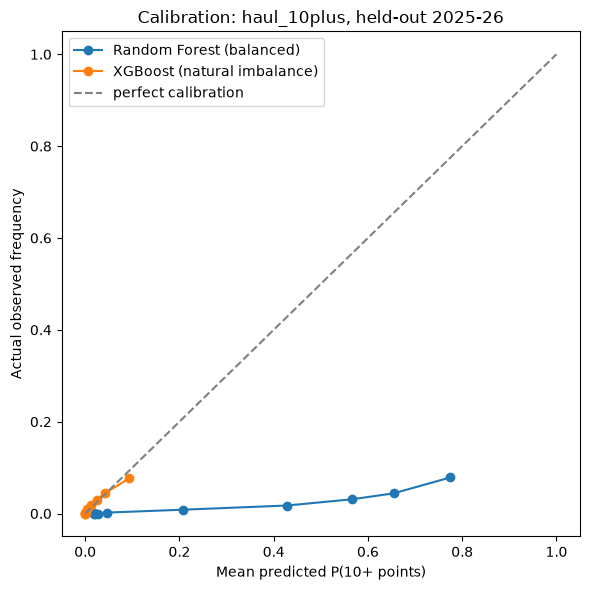

In [3]:
df = build_training_frame()
pos_cols = [c for c in df.columns if c.startswith("pos_")]
feature_cols = FEATURE_COLS + pos_cols
test = df[(df["season"] == TEST_SEASON) & (df["gw_number"] > 1)]
X_test = test[feature_cols].fillna(0.0)
y_test_10 = (test["target_total_points"] >= 10).astype(int)

rf = joblib.load("../models/haul_10plus_random_forest.joblib")
xgb = joblib.load("../models/haul_10plus_xgboost.joblib")

fig, ax = plt.subplots(figsize=(6, 6))
for model, label in [(rf, "Random Forest (balanced)"), (xgb, "XGBoost (natural imbalance)")]:
    p = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test_10, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
ax.set_xlabel("Mean predicted P(10+ points)")
ax.set_ylabel("Actual observed frequency")
ax.set_title("Calibration: haul_10plus, held-out 2025-26")
ax.legend()
plt.tight_layout()
plt.show()

## Live predictions: does it actually differentiate real players?

In [4]:
live = pd.read_sql_query("""
    SELECT p.web_name, pr.predicted_points, pr.p_return_6plus, pr.p_haul_10plus
    FROM predictions pr JOIN players p ON p.player_code = pr.player_code
    ORDER BY pr.p_haul_10plus DESC LIMIT 10
""", conn)
print("Top 10 by ceiling probability, current live GW:")
live

Top 10 by ceiling probability, current live GW:


,web_name,predicted_points,p_return_6plus,p_haul_10plus
0,Saka,3.199,0.3893,0.2272
1,Ødegaard,3.088,0.2115,0.1128
2,Eze,1.627,0.0802,0.0903
3,Milenković,3.087,0.4024,0.0871
4,B.Fernandes,3.704,0.6284,0.0859
5,Dewsbury-Hall,3.776,0.2916,0.0858
6,Trafford,3.404,0.2071,0.0695
7,Bijol,3.008,0.1850,0.0691
8,Kelleher,3.684,0.3447,0.0665
9,Calafiori,3.070,0.2196,0.0661


## Two real bugs caught while wiring this into the live dashboard

1. **`predictions` had accumulated 1804 stale rows** from every past `model_id` â€” the table's primary key includes `model_id`, so `ON CONFLICT` never touched superseded rows from older models. Worse, Postgres sorts `NULL` first in `DESC` by default, so a naive `ORDER BY p_haul_10plus DESC` surfaced only pre-classifier `NULL` rows as the "top" results â€” silently wrong, not an error. Fixed: `predict_live.py` now deletes existing rows for the gameweek before inserting fresh ones.
2. **The dashboard's cached DB connection never set `autocommit=True`**, so it sat idle-in-transaction for hours between Streamlit reruns, holding locks that silently blocked an unrelated schema migration earlier the same session. Fixed at the source â€” a read-only dashboard has nothing to commit anyway.

## Next steps

This closes out Phase 6.5. The captaincy/differential decision layer now has both an expected-points estimate and a calibrated ceiling probability â€” the safe-pick-vs-upside-pick framing the original plan's Risk Model section wanted. Phase 7 (Monte Carlo simulation, injury/news NLP, LLM-generated explanations) is the last fully-unstarted phase from the original plan.

In [5]:
conn.close()